<a href="https://colab.research.google.com/github/Dhushyanthan005/day-1-datascience-question1/blob/main/DS_Day01_14_SaaS_Feature_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Load datasets
accounts = pd.read_csv("/content/ravenstack_accounts.csv")
subscriptions = pd.read_csv("/content/ravenstack_subscriptions.csv")
feature_usage = pd.read_csv("/content/ravenstack_feature_usage.csv")
churn_events = pd.read_csv("/content/ravenstack_churn_events.csv")
support_tickets = pd.read_csv("/content/ravenstack_support_tickets.csv")

# Display dataset sizes
print("Accounts:", accounts.shape)
print("Subscriptions:", subscriptions.shape)
print("Feature Usage:", feature_usage.shape)
print("Churn Events:", churn_events.shape)
print("Support Tickets:", support_tickets.shape)

Accounts: (500, 10)
Subscriptions: (5000, 14)
Feature Usage: (25000, 8)
Churn Events: (600, 9)
Support Tickets: (2000, 9)


In [2]:
print("ACCOUNTS")
print(accounts.columns.tolist())

print("\nSUBSCRIPTIONS")
print(subscriptions.columns.tolist())

print("\nFEATURE USAGE")
print(feature_usage.columns.tolist())

print("\nCHURN EVENTS")
print(churn_events.columns.tolist())

print("\nSUPPORT TICKETS")
print(support_tickets.columns.tolist())

ACCOUNTS
['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']

SUBSCRIPTIONS
['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag']

FEATURE USAGE
['usage_id', 'subscription_id', 'usage_date', 'feature_name', 'usage_count', 'usage_duration_secs', 'error_count', 'is_beta_feature']

CHURN EVENTS
['churn_event_id', 'account_id', 'churn_date', 'reason_code', 'refund_amount_usd', 'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation', 'feedback_text']

SUPPORT TICKETS
['ticket_id', 'account_id', 'submitted_at', 'closed_at', 'resolution_time_hours', 'priority', 'first_response_time_minutes', 'satisfaction_score', 'escalation_flag']


In [3]:
display(accounts.head())

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [4]:
display(subscriptions.head())

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


In [5]:
display(feature_usage.head())

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


In [6]:
accounts_df = accounts.copy()
subscriptions_df = subscriptions.copy()
feature_usage_df = feature_usage.copy()
churn_events_df = churn_events.copy()
support_tickets_df = support_tickets.copy()

In [7]:
accounts_df["signup_date"] = pd.to_datetime(accounts_df["signup_date"])

subscriptions_df["start_date"] = pd.to_datetime(
    subscriptions_df["start_date"]
)

subscriptions_df["end_date"] = pd.to_datetime(
    subscriptions_df["end_date"]
)

feature_usage_df["usage_date"] = pd.to_datetime(
    feature_usage_df["usage_date"]
)

churn_events_df["churn_date"] = pd.to_datetime(
    churn_events_df["churn_date"]
)

support_tickets_df["submitted_at"] = pd.to_datetime(
    support_tickets_df["submitted_at"]
)

support_tickets_df["closed_at"] = pd.to_datetime(
    support_tickets_df["closed_at"]
)

In [8]:
print("=== ACCOUNTS ===")
print(accounts_df.isnull().sum())

print("\n=== SUBSCRIPTIONS ===")
print(subscriptions_df.isnull().sum())

print("\n=== FEATURE USAGE ===")
print(feature_usage_df.isnull().sum())

print("\n=== CHURN EVENTS ===")
print(churn_events_df.isnull().sum())

print("\n=== SUPPORT TICKETS ===")
print(support_tickets_df.isnull().sum())

=== ACCOUNTS ===
account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64

=== SUBSCRIPTIONS ===
subscription_id         0
account_id              0
start_date              0
end_date             4514
plan_tier               0
seats                   0
mrr_amount              0
arr_amount              0
is_trial                0
upgrade_flag            0
downgrade_flag          0
churn_flag              0
billing_frequency       0
auto_renew_flag         0
dtype: int64

=== FEATURE USAGE ===
usage_id               0
subscription_id        0
usage_date             0
feature_name           0
usage_count            0
usage_duration_secs    0
error_count            0
is_beta_feature        0
dtype: int64

=== CHURN EVENTS ===
churn_event_id                0
account_id                    0
churn_date                    0
reason

In [9]:
master_df = feature_usage_df.merge(
    subscriptions_df,
    on="subscription_id",
    how="left",
    suffixes=("_usage", "_subscription")
)

In [10]:
print(master_df.shape)
master_df.head()

(25000, 21)


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False,A-e08cd3,2024-11-23,NaT,Pro,67,3283,39396,False,False,False,False,annual,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False,A-c7ffc2,2023-09-22,NaT,Basic,30,570,6840,False,True,False,False,annual,True
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False,A-bbe56f,2024-10-15,NaT,Basic,22,418,5016,False,False,False,False,annual,True
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False,A-7f29a7,2024-11-24,NaT,Basic,41,779,9348,False,False,False,False,annual,True
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False,A-65a46c,2024-03-07,NaT,Basic,18,342,4104,False,False,False,False,monthly,True


In [11]:
master_df = master_df.merge(
    accounts_df[
        [
            "account_id",
            "account_name",
            "industry",
            "country",
            "signup_date",
            "referral_source"
        ]
    ],
    on="account_id",
    how="left"
)

In [12]:
print(master_df.shape)
master_df.head()

(25000, 26)


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag,account_name,industry,country,signup_date,referral_source
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False,A-e08cd3,2024-11-23,NaT,Pro,67,3283,39396,False,False,False,False,annual,False,Company_475,FinTech,US,2024-09-21,ads
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False,A-c7ffc2,2023-09-22,NaT,Basic,30,570,6840,False,True,False,False,annual,True,Company_392,Cybersecurity,US,2023-01-27,partner
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False,A-bbe56f,2024-10-15,NaT,Basic,22,418,5016,False,False,False,False,annual,True,Company_406,HealthTech,US,2023-02-16,ads
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False,A-7f29a7,2024-11-24,NaT,Basic,41,779,9348,False,False,False,False,annual,True,Company_386,Cybersecurity,UK,2024-09-18,event
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False,A-65a46c,2024-03-07,NaT,Basic,18,342,4104,False,False,False,False,monthly,True,Company_95,HealthTech,US,2023-11-04,event


In [13]:
master_df["User_ID"] = master_df["account_id"]

In [14]:
master_df["Feature_ID"] = master_df["feature_name"]

In [15]:
master_df["Feature_Usage"] = master_df["usage_count"]

In [16]:
master_df["Subscription_Type"] = master_df["plan_tier"]

In [17]:
master_df["Tenure_Days"] = (
    master_df["usage_date"] - master_df["signup_date"]
).dt.days

In [18]:
master_df["Tenure_Months"] = (
    master_df["Tenure_Days"] / 30.44
).round(2)

In [19]:
master_df[
    [
        "User_ID",
        "signup_date",
        "usage_date",
        "Tenure_Months"
    ]
].head(10)

,User_ID,signup_date,usage_date,Tenure_Months
0,A-e08cd3,2024-09-21,2023-07-27,-13.86
1,A-c7ffc2,2023-01-27,2023-08-07,6.31
2,A-bbe56f,2023-02-16,2023-12-07,9.66
3,A-7f29a7,2024-09-18,2024-07-28,-1.71
4,A-65a46c,2023-11-04,2024-12-02,12.94
5,A-417d2f,2023-07-04,2023-10-31,3.91
6,A-5b4ebb,2024-07-10,2023-09-20,-9.66
7,A-eb1312,2024-09-16,2023-06-05,-15.41
8,A-f25509,2024-03-22,2024-02-20,-1.02
9,A-89ee83,2024-10-04,2023-02-09,-19.81


In [20]:
session_counts = (
    master_df
    .groupby("User_ID")
    .size()
    .reset_index(name="Session_Count")
)

In [21]:
master_df = master_df.merge(
    session_counts,
    on="User_ID",
    how="left"
)

In [22]:
session_duration = (
    master_df
    .groupby("User_ID")["usage_duration_secs"]
    .mean()
    .reset_index(name="Session_Duration")
)

In [23]:
master_df = master_df.merge(
    session_duration,
    on="User_ID",
    how="left"
)

In [24]:
master_df["Retention_Status"] = np.where(
    master_df["churn_flag"] == True,
    "Churned",
    "Retained"
)

In [25]:
master_df["Retention_Status"].value_counts()

,count
Retention_Status,
Retained,22627
Churned,2373


In [26]:
analysis_df = master_df[
    [
        "User_ID",
        "Feature_ID",
        "Feature_Usage",
        "Subscription_Type",
        "Tenure_Months",
        "Session_Count",
        "Session_Duration",
        "Retention_Status"
    ]
].copy()

In [27]:
analysis_df.shape

(25000, 8)

In [28]:
analysis_df.to_csv(
    "/content/DS_Day01_14_SaaS_Feature_Analysis.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!


In [29]:
analysis_df.head()
analysis_df.shape
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            25000 non-null  object 
 1   Feature_ID         25000 non-null  object 
 2   Feature_Usage      25000 non-null  int64  
 3   Subscription_Type  25000 non-null  object 
 4   Tenure_Months      25000 non-null  float64
 5   Session_Count      25000 non-null  int64  
 6   Session_Duration   25000 non-null  float64
 7   Retention_Status   25000 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 1.5+ MB


In [30]:
# Check duplicate rows
print("Number of duplicate rows:", analysis_df.duplicated().sum())

Number of duplicate rows: 0


In [31]:
# Remove duplicates if any
analysis_df = analysis_df.drop_duplicates()

print("Shape after removing duplicates:", analysis_df.shape)

Shape after removing duplicates: (25000, 8)


In [32]:
print("Missing values in each column:")
print(analysis_df.isnull().sum())

Missing values in each column:
User_ID              0
Feature_ID           0
Feature_Usage        0
Subscription_Type    0
Tenure_Months        0
Session_Count        0
Session_Duration     0
Retention_Status     0
dtype: int64


In [33]:
print("Subscription Types:")
print(analysis_df["Subscription_Type"].value_counts())

Subscription Types:
Subscription_Type
Enterprise    8580
Pro           8440
Basic         7980
Name: count, dtype: int64


In [34]:
print("\nRetention Status:")
print(analysis_df["Retention_Status"].value_counts())


Retention Status:
Retention_Status
Retained    22627
Churned      2373
Name: count, dtype: int64


In [35]:
print("\nNumber of unique features:",
      analysis_df["Feature_ID"].nunique())

print("\nFeature list:")
print(sorted(analysis_df["Feature_ID"].unique()))


Number of unique features: 40

Feature list:
['feature_1', 'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14', 'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19', 'feature_2', 'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24', 'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29', 'feature_3', 'feature_30', 'feature_31', 'feature_32', 'feature_33', 'feature_34', 'feature_35', 'feature_36', 'feature_37', 'feature_38', 'feature_39', 'feature_4', 'feature_40', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9']


In [36]:
analysis_df[
    [
        "Feature_Usage",
        "Tenure_Months",
        "Session_Count",
        "Session_Duration"
    ]
].describe()

,Feature_Usage,Tenure_Months,Session_Count,Session_Duration
count,25000.000000,25000.000000,25000.000000,25000.000000
mean,10.021000,-0.719594,55.897200,3042.202880
std,3.143729,9.800957,16.614796,285.840647
min,0.000000,-23.780000,10.000000,1543.266667
25%,8.000000,-7.920000,45.000000,2862.422222
50%,10.000000,-0.660000,56.000000,3028.652174
75%,12.000000,6.180000,67.000000,3216.670732
max,26.000000,23.590000,101.000000,4199.722222


In [37]:
print("Negative Feature Usage:",
      (analysis_df["Feature_Usage"] < 0).sum())

print("Negative Tenure:",
      (analysis_df["Tenure_Months"] < 0).sum())

print("Negative Session Count:",
      (analysis_df["Session_Count"] < 0).sum())

print("Negative Session Duration:",
      (analysis_df["Session_Duration"] < 0).sum())

Negative Feature Usage: 0
Negative Tenure: 13198
Negative Session Count: 0
Negative Session Duration: 0


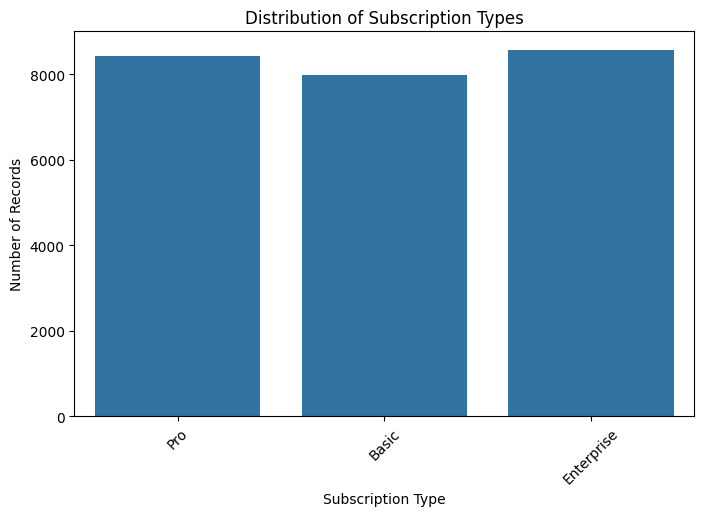

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=analysis_df,
    x="Subscription_Type"
)

plt.title("Distribution of Subscription Types")
plt.xlabel("Subscription Type")
plt.ylabel("Number of Records")

plt.xticks(rotation=45)
plt.show()

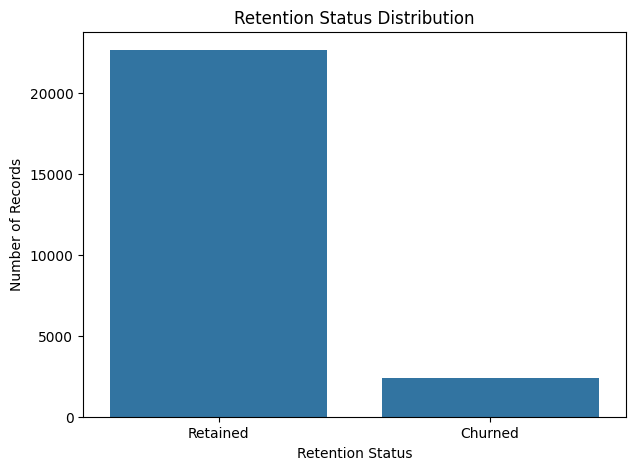

In [39]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=analysis_df,
    x="Retention_Status"
)

plt.title("Retention Status Distribution")
plt.xlabel("Retention Status")
plt.ylabel("Number of Records")

plt.show()

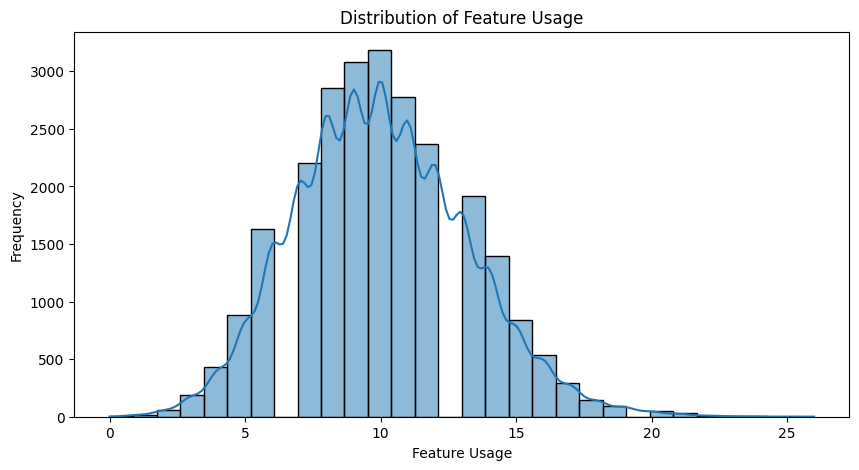

In [40]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=analysis_df,
    x="Feature_Usage",
    bins=30,
    kde=True
)

plt.title("Distribution of Feature Usage")
plt.xlabel("Feature Usage")
plt.ylabel("Frequency")

plt.show()

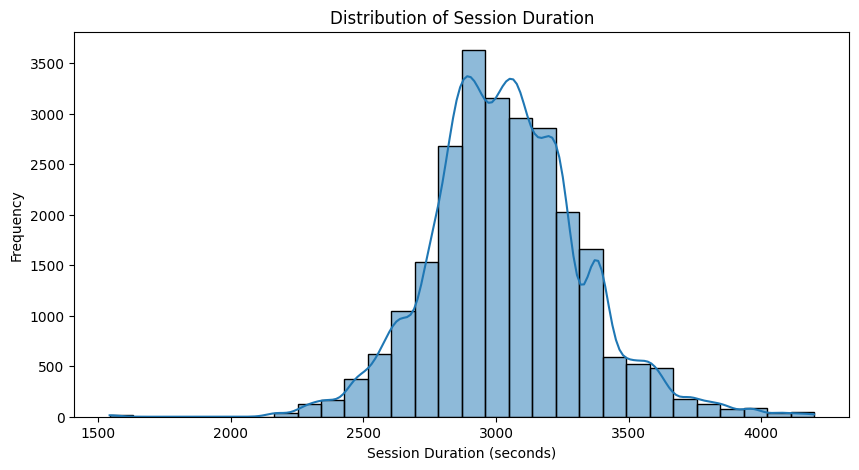

In [41]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=analysis_df,
    x="Session_Duration",
    bins=30,
    kde=True
)

plt.title("Distribution of Session Duration")
plt.xlabel("Session Duration (seconds)")
plt.ylabel("Frequency")

plt.show()

In [42]:
analysis_df["Feature_Adopted"] = (
    analysis_df["Feature_Usage"] > 0
)

In [43]:
analysis_df["Feature_Adopted"].value_counts()

,count
Feature_Adopted,
True,24998
False,2


In [44]:
feature_adoption = (
    analysis_df
    .groupby("Feature_ID")
    .agg(
        Total_Users=("User_ID", "nunique"),
        Adopted_Users=("Feature_Adopted", "sum")
    )
    .reset_index()
)

feature_adoption["Adoption_Rate"] = (
    feature_adoption["Adopted_Users"] /
    feature_adoption["Total_Users"] * 100
)

feature_adoption = feature_adoption.sort_values(
    "Adoption_Rate",
    ascending=False
)

feature_adoption

,Feature_ID,Total_Users,Adopted_Users,Adoption_Rate
12,feature_20,334,643,192.514970
36,feature_6,342,655,191.520468
14,feature_22,334,636,190.419162
24,feature_31,339,644,189.970501
21,feature_29,338,640,189.349112
1,feature_10,337,634,188.130564
25,feature_32,354,659,186.158192
26,feature_33,342,635,185.672515
2,feature_11,347,643,185.302594
0,feature_1,340,629,185.000000


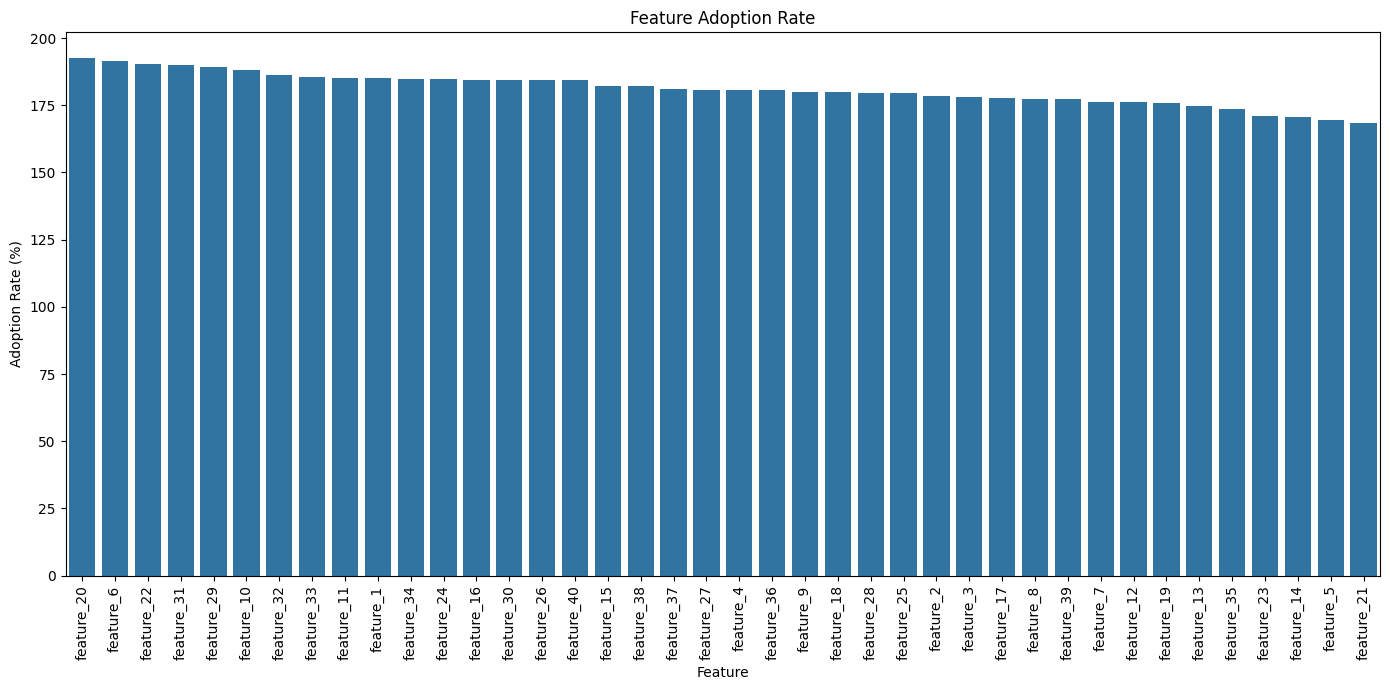

In [45]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=feature_adoption,
    x="Feature_ID",
    y="Adoption_Rate"
)

plt.title("Feature Adoption Rate")
plt.xlabel("Feature")
plt.ylabel("Adoption Rate (%)")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [46]:
analysis_df["Retention_Binary"] = (
    analysis_df["Retention_Status"] == "Retained"
).astype(int)

In [47]:
feature_analysis = (
    analysis_df
    .groupby("Feature_ID")
    .agg(
        Avg_Usage=("Feature_Usage", "mean"),
        Adoption_Rate=("Feature_Adopted", "mean"),
        Retention_Rate=("Retention_Binary", "mean"),
        Avg_Session_Count=("Session_Count", "mean"),
        Avg_Session_Duration=("Session_Duration", "mean")
    )
    .reset_index()
)

In [48]:
feature_analysis["Adoption_Rate"] *= 100
feature_analysis["Retention_Rate"] *= 100

In [49]:
feature_analysis.sort_values(
    "Retention_Rate",
    ascending=False
)

,Feature_ID,Avg_Usage,Adoption_Rate,Retention_Rate,Avg_Session_Count,Avg_Session_Duration
19,feature_27,10.198036,100.000000,92.962357,55.420622,3033.275503
8,feature_17,9.920123,100.000000,92.933948,55.204301,3047.612071
22,feature_3,9.894649,100.000000,92.474916,57.117057,3062.456383
7,feature_16,10.085209,100.000000,92.443730,55.808682,3062.942138
37,feature_7,9.875606,100.000000,92.245557,55.143780,3049.069979
16,feature_24,9.934681,100.000000,92.223950,55.598756,3034.570091
18,feature_26,9.969183,100.000000,92.141757,56.046225,3036.495673
27,feature_34,10.055385,99.846154,92.000000,56.329231,3053.190270
32,feature_39,10.190174,100.000000,91.600634,56.093502,3030.953176
26,feature_33,9.880315,100.000000,91.181102,54.903937,3045.765002


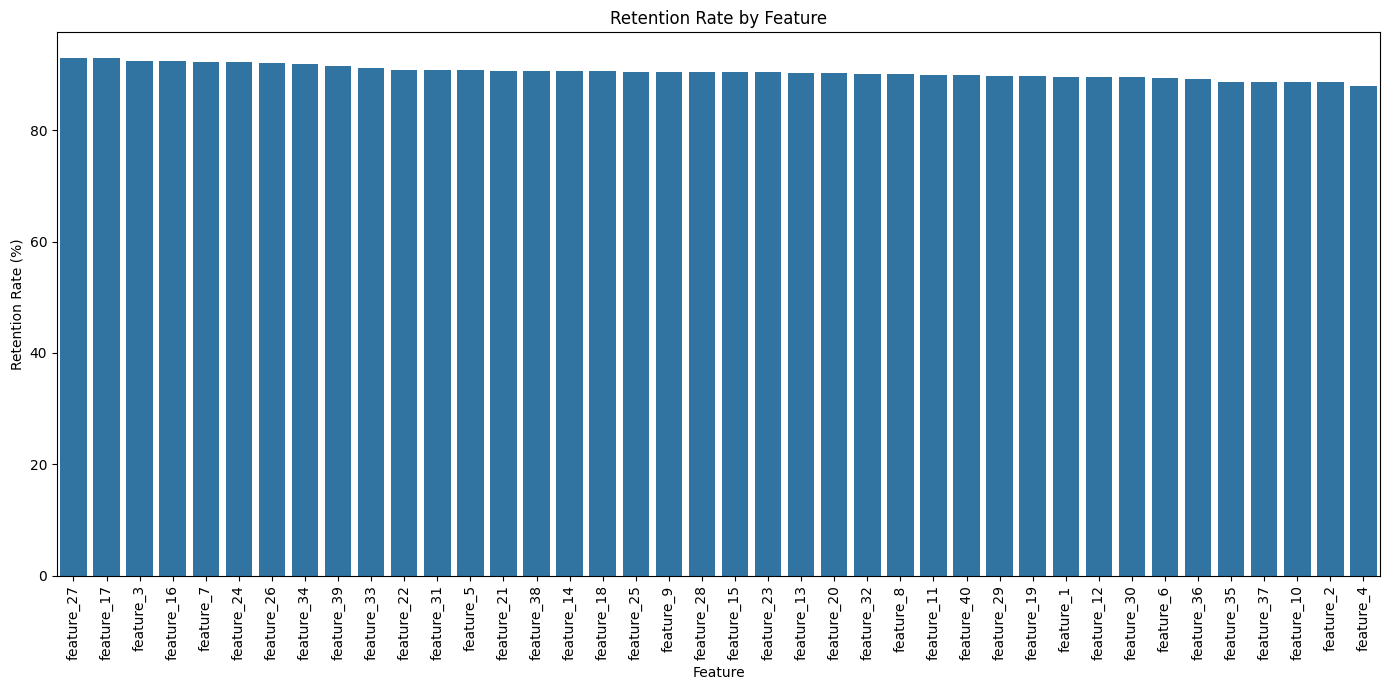

In [50]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=feature_analysis.sort_values(
        "Retention_Rate",
        ascending=False
    ),
    x="Feature_ID",
    y="Retention_Rate"
)

plt.title("Retention Rate by Feature")
plt.xlabel("Feature")
plt.ylabel("Retention Rate (%)")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

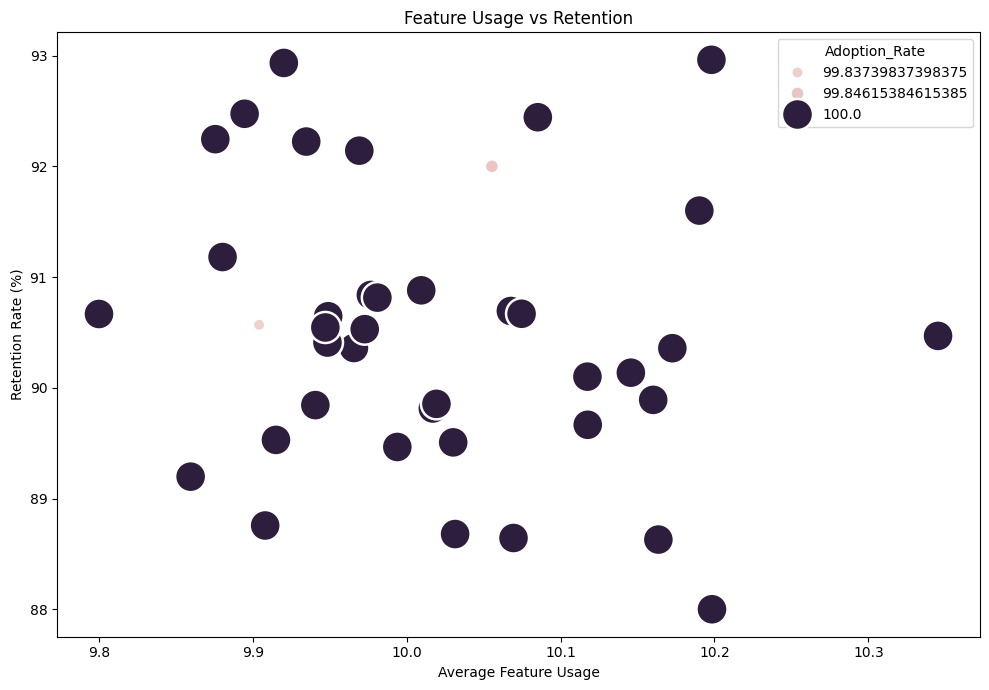

In [51]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=feature_analysis,
    x="Avg_Usage",
    y="Retention_Rate",
    size="Adoption_Rate",
    hue="Adoption_Rate",
    sizes=(80,500)
)

plt.title("Feature Usage vs Retention")
plt.xlabel("Average Feature Usage")
plt.ylabel("Retention Rate (%)")

plt.tight_layout()
plt.show()

In [52]:
usage_threshold = feature_analysis["Avg_Usage"].median()
retention_threshold = feature_analysis["Retention_Rate"].median()

high_usage_low_retention = feature_analysis[
    (feature_analysis["Avg_Usage"] > usage_threshold) &
    (feature_analysis["Retention_Rate"] < retention_threshold)
]

print("High Usage + Low Retention Features:")
display(
    high_usage_low_retention.sort_values(
        "Avg_Usage",
        ascending=False
    )
)

High Usage + Low Retention Features:


,Feature_ID,Avg_Usage,Adoption_Rate,Retention_Rate,Avg_Session_Count,Avg_Session_Duration
6,feature_15,10.345313,100.0,90.468750,56.571875,3043.857059
33,feature_4,10.198400,100.0,88.000000,55.742400,3042.175867
12,feature_20,10.172628,100.0,90.357698,55.107309,3044.984613
11,feature_2,10.163551,100.0,88.629283,55.098131,3018.382872
2,feature_11,10.160187,100.0,89.891135,56.069984,3030.525743
25,feature_32,10.145675,100.0,90.136571,56.198786,3069.542138
0,feature_1,10.117647,100.0,89.666137,56.607313,3032.845241
38,feature_8,10.117450,100.0,90.100671,55.318792,3027.862426
1,feature_10,10.069401,100.0,88.643533,55.804416,3060.227222
30,feature_37,10.031447,100.0,88.679245,56.943396,3027.320860


In [53]:
print("Total unique users:",
      analysis_df["User_ID"].nunique())

print("Total unique features:",
      analysis_df["Feature_ID"].nunique())

print("\nFeature usage minimum:")
print(
    analysis_df.groupby("Feature_ID")["Feature_Usage"]
    .min()
    .sort_values()
)

Total unique users: 500
Total unique features: 40

Feature usage minimum:
Feature_ID
feature_34    0
feature_25    0
feature_10    1
feature_14    1
feature_22    1
feature_28    1
feature_17    1
feature_39    1
feature_7     1
feature_40    1
feature_4     1
feature_9     1
feature_16    2
feature_15    2
feature_19    2
feature_12    2
feature_23    2
feature_21    2
feature_20    2
feature_26    2
feature_27    2
feature_29    2
feature_3     2
feature_24    2
feature_35    2
feature_31    2
feature_32    2
feature_18    2
feature_2     2
feature_13    2
feature_11    2
feature_1     2
feature_33    2
feature_5     2
feature_37    2
feature_38    2
feature_6     2
feature_8     2
feature_36    3
feature_30    3
Name: Feature_Usage, dtype: int64


In [54]:
usage_zero_check = (
    analysis_df.groupby("Feature_ID")["Feature_Usage"]
    .apply(lambda x: (x == 0).sum())
    .reset_index(name="Zero_Usage_Records")
)

usage_zero_check

,Feature_ID,Zero_Usage_Records
0,feature_1,0
1,feature_10,0
2,feature_11,0
3,feature_12,0
4,feature_13,0
5,feature_14,0
6,feature_15,0
7,feature_16,0
8,feature_17,0
9,feature_18,0


In [55]:
feature_analysis = (
    analysis_df
    .groupby("Feature_ID")
    .agg(
        Total_Usage=("Feature_Usage", "sum"),
        Avg_Usage=("Feature_Usage", "mean"),
        Retention_Rate=("Retention_Binary", "mean"),
        Avg_Session_Count=("Session_Count", "mean"),
        Avg_Session_Duration=("Session_Duration", "mean"),
        Users=("User_ID", "nunique")
    )
    .reset_index()
)

feature_analysis["Retention_Rate"] *= 100

In [56]:
total_usage = feature_analysis["Total_Usage"].sum()

feature_analysis["Usage_Share"] = (
    feature_analysis["Total_Usage"] /
    total_usage * 100
)

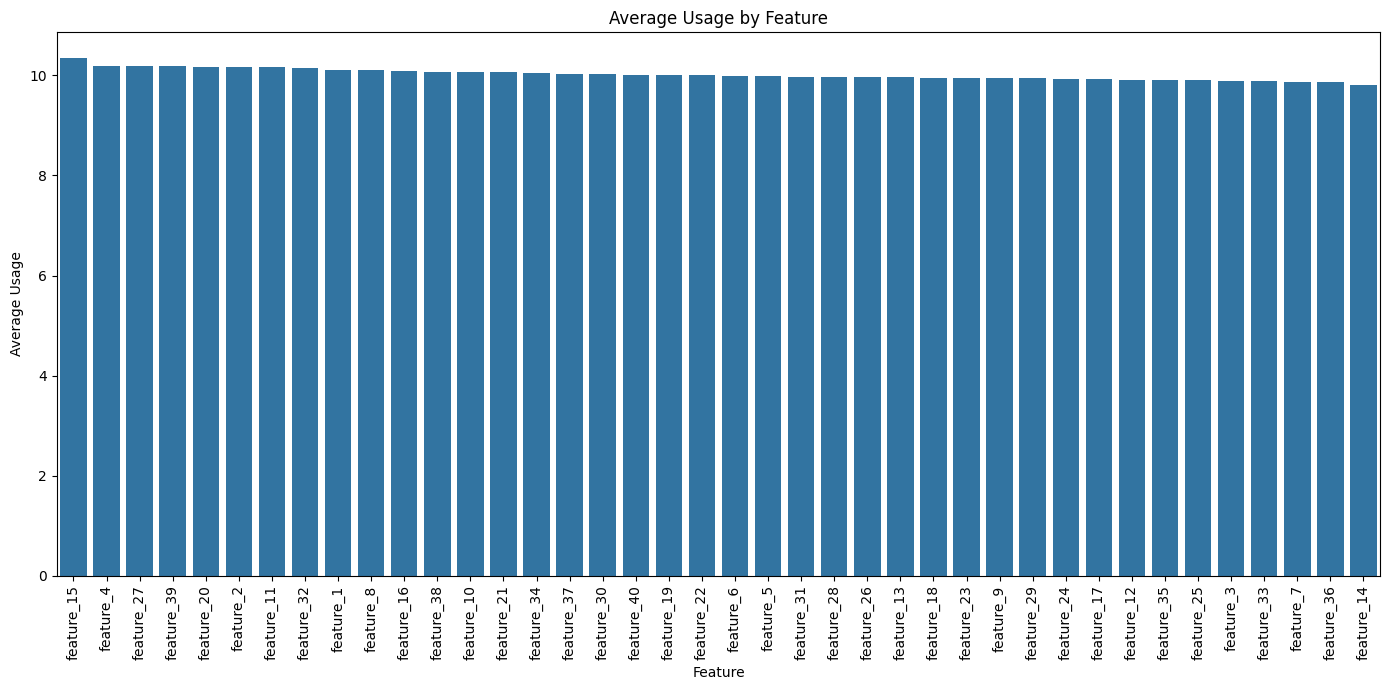

In [57]:
plt.figure(figsize=(14,7))

plot_data = feature_analysis.sort_values(
    "Avg_Usage",
    ascending=False
)

sns.barplot(
    data=plot_data,
    x="Feature_ID",
    y="Avg_Usage"
)

plt.title("Average Usage by Feature")
plt.xlabel("Feature")
plt.ylabel("Average Usage")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [58]:
usage_median = feature_analysis["Avg_Usage"].median()
retention_median = feature_analysis["Retention_Rate"].median()

feature_analysis["Usage_Level"] = np.where(
    feature_analysis["Avg_Usage"] >= usage_median,
    "High Usage",
    "Low Usage"
)

feature_analysis["Retention_Level"] = np.where(
    feature_analysis["Retention_Rate"] >= retention_median,
    "High Retention",
    "Low Retention"
)

feature_analysis["Feature_Group"] = (
    feature_analysis["Usage_Level"]
    + " + "
    + feature_analysis["Retention_Level"]
)

display(
    feature_analysis[
        [
            "Feature_ID",
            "Avg_Usage",
            "Retention_Rate",
            "Feature_Group"
        ]
    ].sort_values("Avg_Usage", ascending=False)
)

,Feature_ID,Avg_Usage,Retention_Rate,Feature_Group
6,feature_15,10.345313,90.468750,High Usage + Low Retention
33,feature_4,10.198400,88.000000,High Usage + Low Retention
19,feature_27,10.198036,92.962357,High Usage + High Retention
32,feature_39,10.190174,91.600634,High Usage + High Retention
12,feature_20,10.172628,90.357698,High Usage + Low Retention
11,feature_2,10.163551,88.629283,High Usage + Low Retention
2,feature_11,10.160187,89.891135,High Usage + Low Retention
25,feature_32,10.145675,90.136571,High Usage + Low Retention
0,feature_1,10.117647,89.666137,High Usage + Low Retention
38,feature_8,10.117450,90.100671,High Usage + Low Retention


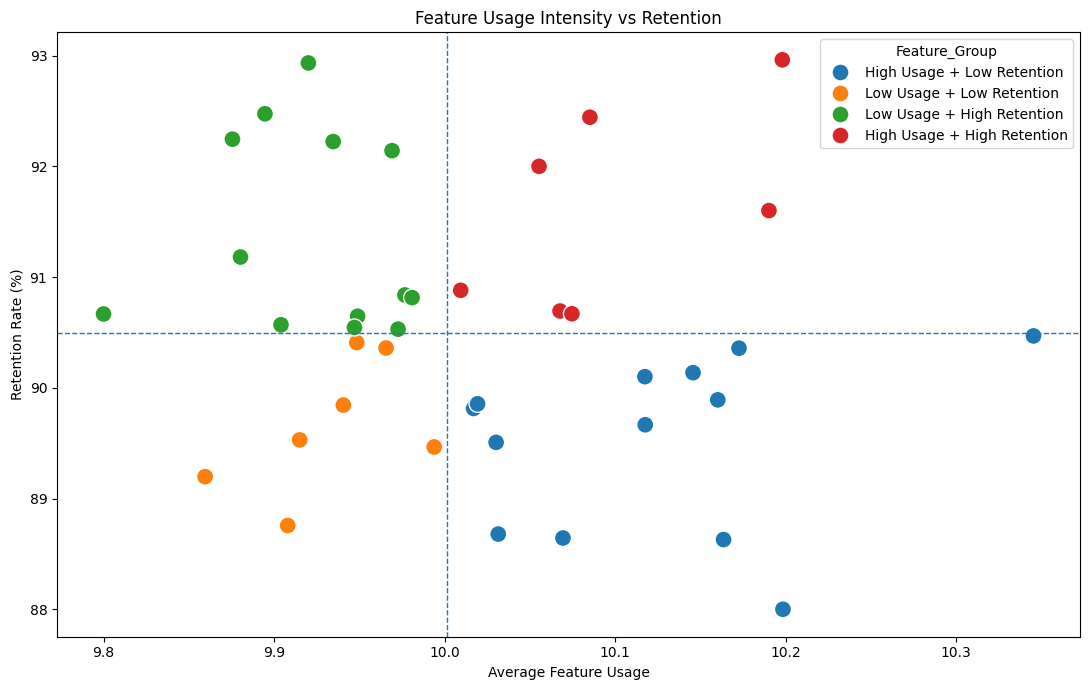

In [59]:
plt.figure(figsize=(11,7))

sns.scatterplot(
    data=feature_analysis,
    x="Avg_Usage",
    y="Retention_Rate",
    hue="Feature_Group",
    s=150
)

plt.axvline(
    usage_median,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    retention_median,
    linestyle="--",
    linewidth=1
)

plt.title("Feature Usage Intensity vs Retention")
plt.xlabel("Average Feature Usage")
plt.ylabel("Retention Rate (%)")

plt.tight_layout()
plt.show()

In [60]:
user_behavior = (
    analysis_df
    .groupby("User_ID")
    .agg(
        Total_Feature_Usage=("Feature_Usage", "sum"),
        Avg_Feature_Usage=("Feature_Usage", "mean"),
        Features_Used=("Feature_ID", "nunique"),
        Session_Count=("Session_Count", "first"),
        Session_Duration=("Session_Duration", "first"),
        Tenure_Months=("Tenure_Months", "first"),
        Retention=("Retention_Binary", "first"),
        Subscription_Type=("Subscription_Type", "first")
    )
    .reset_index()
)

user_behavior.head()

,User_ID,Total_Feature_Usage,Avg_Feature_Usage,Features_Used,Session_Count,Session_Duration,Tenure_Months,Retention,Subscription_Type
0,A-00bed1,514,10.078431,32,51,2818.313725,11.10,1,Basic
1,A-00cac8,602,10.379310,30,58,2954.586207,8.74,1,Enterprise
2,A-0158bb,364,10.111111,19,36,3390.305556,2.76,1,Enterprise
3,A-016043,490,10.425532,26,47,2810.106383,2.66,1,Enterprise
4,A-019782,562,10.218182,28,55,2924.509091,15.37,1,Pro


In [61]:
user_behavior.describe()

,Total_Feature_Usage,Avg_Feature_Usage,Features_Used,Session_Count,Session_Duration,Tenure_Months,Retention
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000
mean,501.05000,10.019730,27.616000,50.000000,3056.326634,-1.10008,0.898000
std,173.81891,0.464163,5.658673,17.188685,320.061576,10.15718,0.302951
min,92.00000,8.090909,9.000000,10.000000,1543.266667,-22.14000,0.000000
25%,373.00000,9.723404,24.000000,38.000000,2852.023810,-8.75500,1.000000
50%,498.50000,10.021981,28.000000,50.000000,3033.168615,-1.48000,1.000000
75%,619.25000,10.308042,32.000000,62.000000,3235.928744,5.98750,1.000000
max,1053.00000,11.555556,40.000000,101.000000,4199.722222,23.06000,1.000000


In [62]:
usage_median = user_behavior["Total_Feature_Usage"].median()
features_median = user_behavior["Features_Used"].median()
session_median = user_behavior["Session_Count"].median()

print("Median Total Feature Usage:", usage_median)
print("Median Features Used:", features_median)
print("Median Session Count:", session_median)

Median Total Feature Usage: 498.5
Median Features Used: 28.0
Median Session Count: 50.0


In [63]:
def segment_user(row):

    high_usage = row["Total_Feature_Usage"] >= usage_median
    many_features = row["Features_Used"] >= features_median
    high_sessions = row["Session_Count"] >= session_median

    score = sum([
        high_usage,
        many_features,
        high_sessions
    ])

    if score == 3:
        return "Highly Engaged"

    elif score == 2:
        return "Moderately Engaged"

    else:
        return "Low Engagement"


user_behavior["User_Segment"] = user_behavior.apply(
    segment_user,
    axis=1
)

In [64]:
user_behavior["User_Segment"].value_counts()

,count
User_Segment,
Low Engagement,243
Highly Engaged,227
Moderately Engaged,30


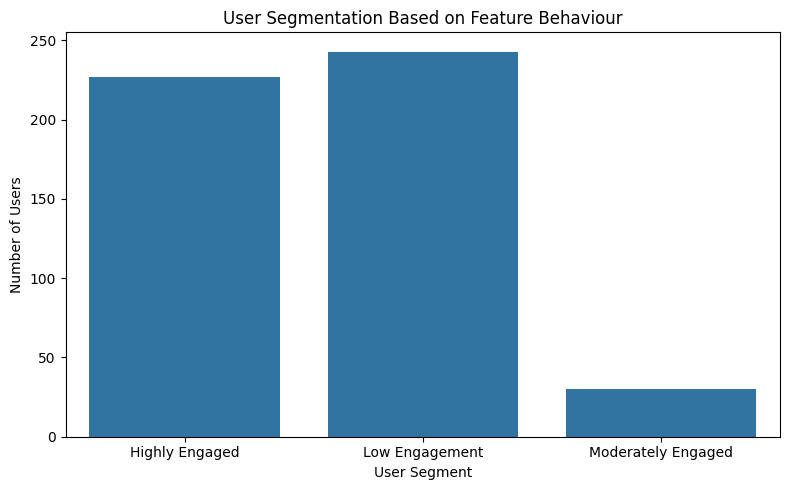

In [65]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=user_behavior,
    x="User_Segment"
)

plt.title("User Segmentation Based on Feature Behaviour")
plt.xlabel("User Segment")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

In [68]:
segment_retention = (
    user_behavior
    .groupby("User_Segment")["Retention"]
    .mean()
    .reset_index(name="Retention_Rate")
)

segment_retention["Retention_Rate"] *= 100

segment_retention

,User_Segment,Retention_Rate
0,Highly Engaged,92.070485
1,Low Engagement,87.242798
2,Moderately Engaged,93.333333


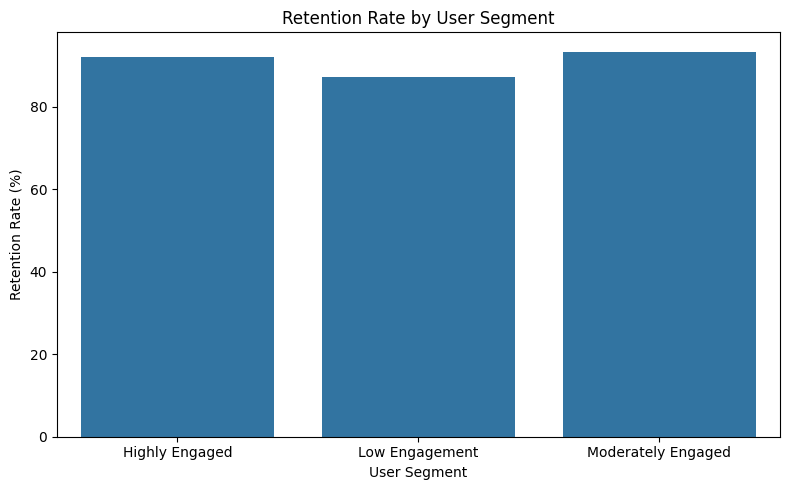

In [69]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_retention,
    x="User_Segment",
    y="Retention_Rate"
)

plt.title("Retention Rate by User Segment")
plt.xlabel("User Segment")
plt.ylabel("Retention Rate (%)")

plt.tight_layout()
plt.show()

In [70]:
print("User Segments:")
print(user_behavior["User_Segment"].value_counts())

User Segments:
User_Segment
Low Engagement        243
Highly Engaged        227
Moderately Engaged     30
Name: count, dtype: int64


In [71]:
print("\nOverall Retention:")
print(user_behavior["Retention"].value_counts())


Overall Retention:
Retention
1    449
0     51
Name: count, dtype: int64


In [72]:
segment_retention

,User_Segment,Retention_Rate
0,Highly Engaged,92.070485
1,Low Engagement,87.242798
2,Moderately Engaged,93.333333


In [73]:
segment_retention.sort_values(
    "Retention_Rate",
    ascending=False
)

,User_Segment,Retention_Rate
2,Moderately Engaged,93.333333
0,Highly Engaged,92.070485
1,Low Engagement,87.242798


In [74]:
model_df = user_behavior[
    [
        "Total_Feature_Usage",
        "Avg_Feature_Usage",
        "Features_Used",
        "Session_Count",
        "Session_Duration",
        "Tenure_Months",
        "Subscription_Type",
        "Retention"
    ]
].copy()

model_df.head()

,Total_Feature_Usage,Avg_Feature_Usage,Features_Used,Session_Count,Session_Duration,Tenure_Months,Subscription_Type,Retention
0,514,10.078431,32,51,2818.313725,11.10,Basic,1
1,602,10.379310,30,58,2954.586207,8.74,Enterprise,1
2,364,10.111111,19,36,3390.305556,2.76,Enterprise,1
3,490,10.425532,26,47,2810.106383,2.66,Enterprise,1
4,562,10.218182,28,55,2924.509091,15.37,Pro,1


In [75]:
model_df = pd.get_dummies(
    model_df,
    columns=["Subscription_Type"],
    drop_first=True
)

model_df.head()

,Total_Feature_Usage,Avg_Feature_Usage,Features_Used,Session_Count,Session_Duration,Tenure_Months,Retention,Subscription_Type_Enterprise,Subscription_Type_Pro
0,514,10.078431,32,51,2818.313725,11.10,1,False,False
1,602,10.379310,30,58,2954.586207,8.74,1,True,False
2,364,10.111111,19,36,3390.305556,2.76,1,True,False
3,490,10.425532,26,47,2810.106383,2.66,1,True,False
4,562,10.218182,28,55,2924.509091,15.37,1,False,True


In [76]:
X = model_df.drop("Retention", axis=1)
y = model_df["Retention"]

print("Features:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

Features:
['Total_Feature_Usage', 'Avg_Feature_Usage', 'Features_Used', 'Session_Count', 'Session_Duration', 'Tenure_Months', 'Subscription_Type_Enterprise', 'Subscription_Type_Pro']

Target distribution:
Retention
1    449
0     51
Name: count, dtype: int64


In [77]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 400
Testing samples: 100


In [78]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [79]:
y_pred = dt_model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1
 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [80]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Decision Tree Evaluation")
print("------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Decision Tree Evaluation
------------------------
Accuracy : 0.8500
Precision: 0.8947
Recall   : 0.9444
F1 Score : 0.9189


In [81]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Decision Tree Evaluation")
print("------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Decision Tree Evaluation
------------------------
Accuracy : 0.8500
Precision: 0.8947
Recall   : 0.9444
F1 Score : 0.9189


In [82]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Churned", "Retained"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Churned       0.00      0.00      0.00        10
    Retained       0.89      0.94      0.92        90

    accuracy                           0.85       100
   macro avg       0.45      0.47      0.46       100
weighted avg       0.81      0.85      0.83       100



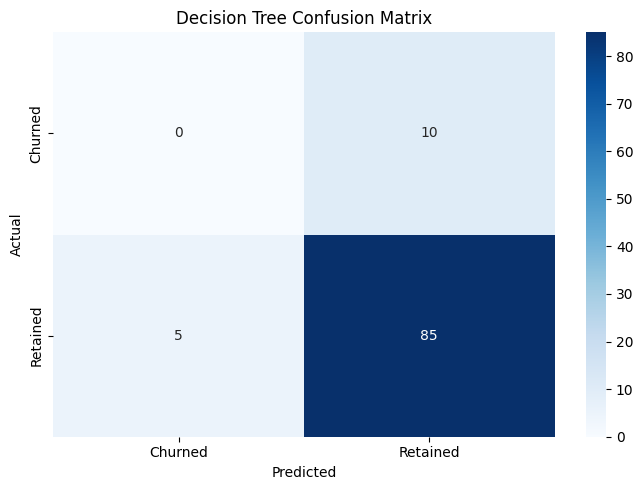

In [83]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Churned", "Retained"],
    yticklabels=["Churned", "Retained"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [84]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
4,Session_Duration,0.374968
5,Tenure_Months,0.249354
1,Avg_Feature_Usage,0.188865
2,Features_Used,0.114585
3,Session_Count,0.072228
0,Total_Feature_Usage,0.000000
6,Subscription_Type_Enterprise,0.000000
7,Subscription_Type_Pro,0.000000


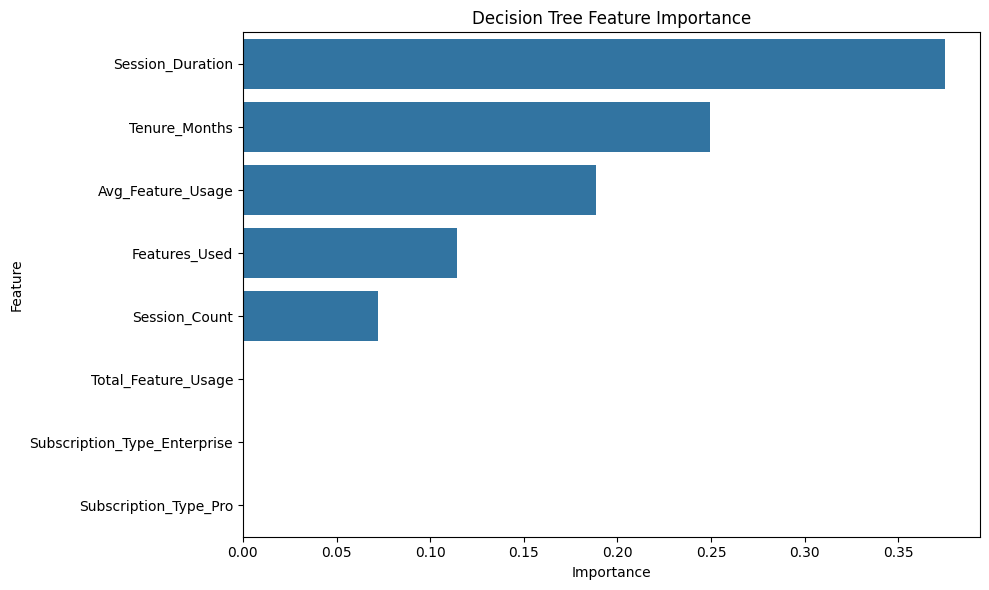

In [85]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

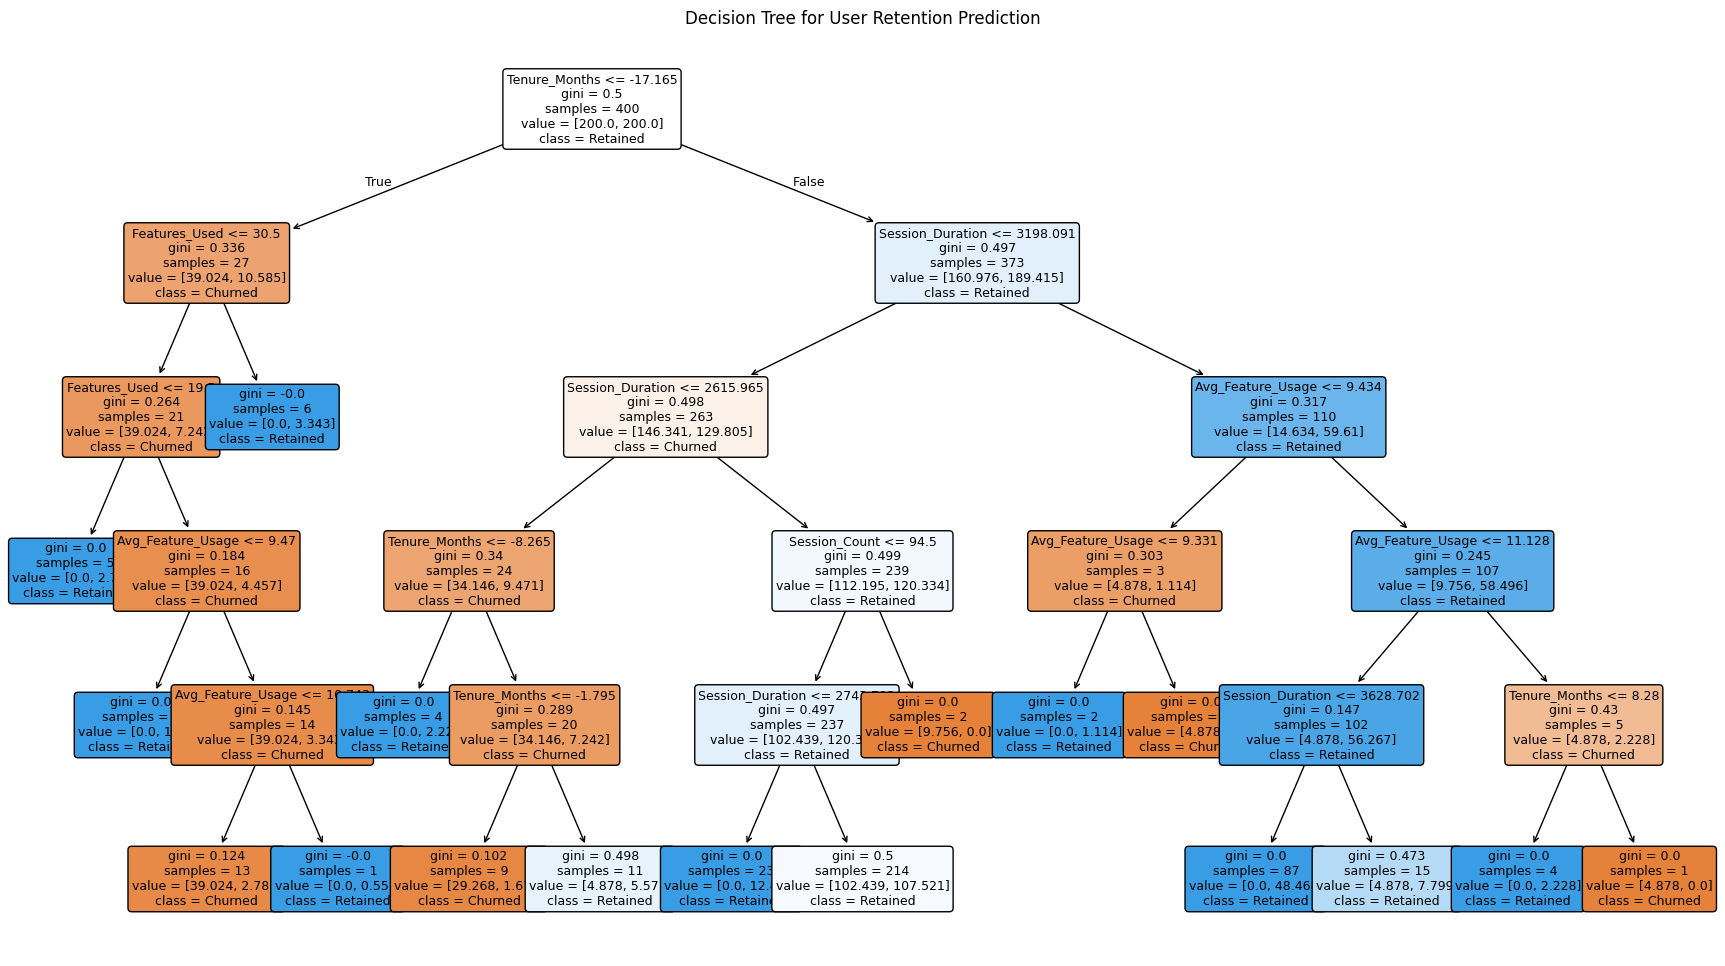

In [86]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22,12))

plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["Churned", "Retained"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree for User Retention Prediction")
plt.show()

In [87]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Macro:")
print(grid_search.best_score_)

Best Parameters:
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross-Validation F1 Macro:
0.5134350912511942


In [88]:
best_dt = grid_search.best_estimator_

y_pred_tuned = best_dt.predict(X_test)

In [89]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report
)

print("TUNED DECISION TREE")
print("-------------------")

print("Accuracy:",
      round(accuracy_score(y_test, y_pred_tuned), 4))

print("Balanced Accuracy:",
      round(balanced_accuracy_score(y_test, y_pred_tuned), 4))

print("Precision:",
      round(precision_score(
          y_test,
          y_pred_tuned,
          zero_division=0
      ), 4))

print("Recall:",
      round(recall_score(
          y_test,
          y_pred_tuned,
          zero_division=0
      ), 4))

print("F1:",
      round(f1_score(
          y_test,
          y_pred_tuned,
          zero_division=0
      ), 4))

TUNED DECISION TREE
-------------------
Accuracy: 0.72
Balanced Accuracy: 0.4
Precision: 0.878
Recall: 0.8
F1: 0.8372


In [90]:
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=["Churned", "Retained"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Churned       0.00      0.00      0.00        10
    Retained       0.88      0.80      0.84        90

    accuracy                           0.72       100
   macro avg       0.44      0.40      0.42       100
weighted avg       0.79      0.72      0.75       100



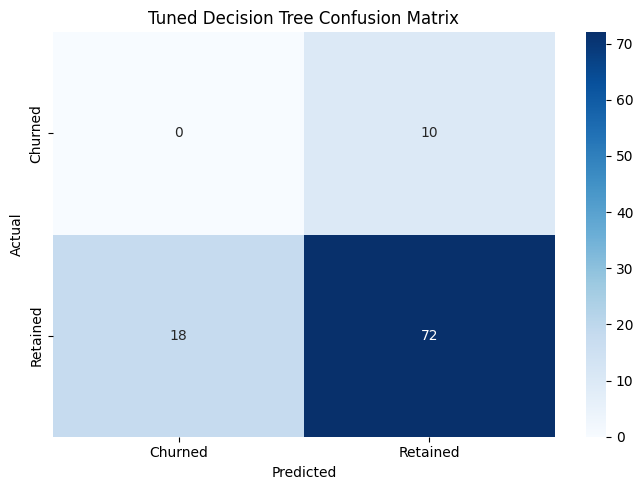

In [91]:
from sklearn.metrics import confusion_matrix

cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Churned", "Retained"],
    yticklabels=["Churned", "Retained"]
)

plt.title("Tuned Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [92]:
print("Test set distribution:")
print(y_test.value_counts())

Test set distribution:
Retention
1    90
0    10
Name: count, dtype: int64


In [93]:
tuned_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_dt.feature_importances_
})

tuned_importance = tuned_importance.sort_values(
    "Importance",
    ascending=False
)

display(tuned_importance)

,Feature,Importance
5,Tenure_Months,3.006516e-01
4,Session_Duration,2.873730e-01
1,Avg_Feature_Usage,2.248174e-01
2,Features_Used,7.540413e-02
3,Session_Count,6.056012e-02
0,Total_Feature_Usage,4.922454e-02
6,Subscription_Type_Enterprise,1.969206e-03
7,Subscription_Type_Pro,2.929298e-17


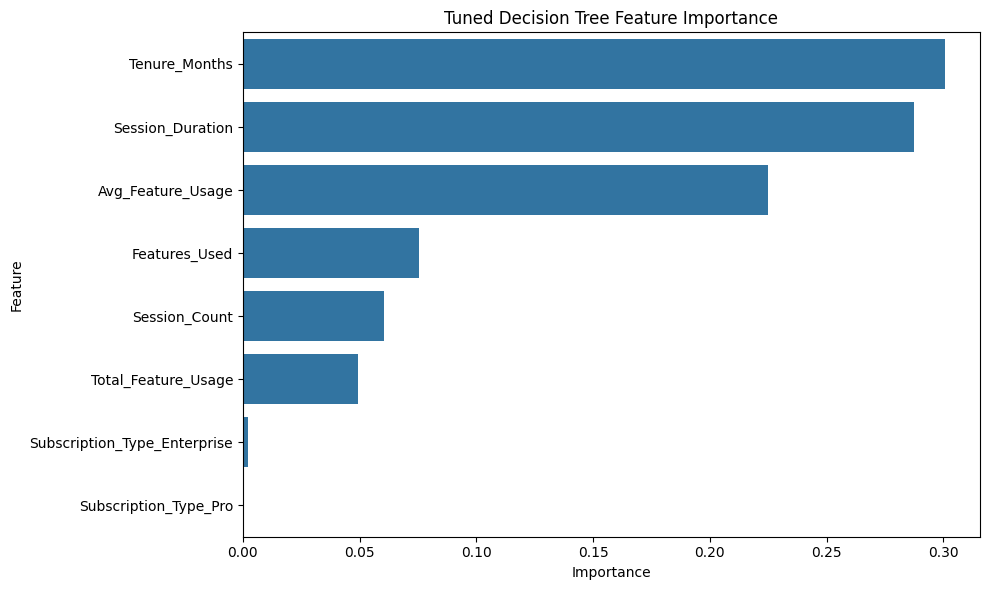

In [94]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=tuned_importance,
    x="Importance",
    y="Feature"
)

plt.title("Tuned Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [95]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [100]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=["Churned", "Retained"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Churned       0.00      0.00      0.00        10
    Retained       0.88      0.80      0.84        90

    accuracy                           0.72       100
   macro avg       0.44      0.40      0.42       100
weighted avg       0.79      0.72      0.75       100



In [101]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

print("TUNED DECISION TREE RESULTS")
print("=" * 35)

print(f"Accuracy:          {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision:         {precision_score(y_test, y_pred_tuned, zero_division=0):.4f}")
print(f"Recall:            {recall_score(y_test, y_pred_tuned, zero_division=0):.4f}")
print(f"F1 Score:          {f1_score(y_test, y_pred_tuned, zero_division=0):.4f}")

TUNED DECISION TREE RESULTS
Accuracy:          0.7200
Balanced Accuracy: 0.4000
Precision:         0.8780
Recall:            0.8000
F1 Score:          0.8372


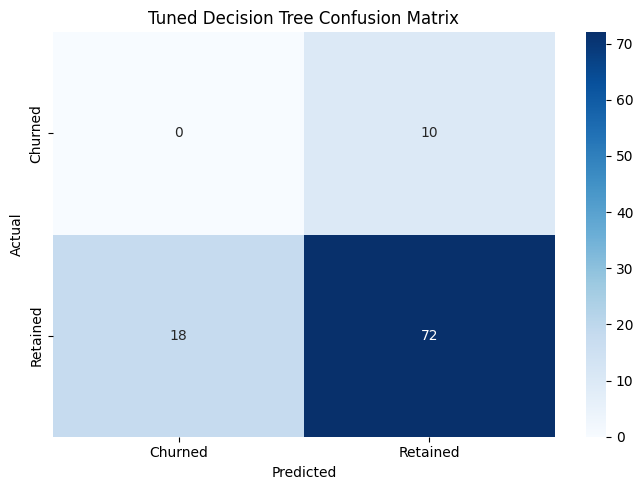

In [102]:
from sklearn.metrics import confusion_matrix

cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Churned", "Retained"],
    yticklabels=["Churned", "Retained"]
)

plt.title("Tuned Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [103]:
tuned_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_dt.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(tuned_importance)

,Feature,Importance
5,Tenure_Months,3.006516e-01
4,Session_Duration,2.873730e-01
1,Avg_Feature_Usage,2.248174e-01
2,Features_Used,7.540413e-02
3,Session_Count,6.056012e-02
0,Total_Feature_Usage,4.922454e-02
6,Subscription_Type_Enterprise,1.969206e-03
7,Subscription_Type_Pro,2.929298e-17


In [104]:
print("USER SEGMENT COUNTS")
print(user_behavior["User_Segment"].value_counts())

print("\nRETENTION BY USER SEGMENT")
display(
    segment_retention.sort_values(
        "Retention_Rate",
        ascending=False
    )
)

USER SEGMENT COUNTS
User_Segment
Low Engagement        243
Highly Engaged        227
Moderately Engaged     30
Name: count, dtype: int64

RETENTION BY USER SEGMENT


,User_Segment,Retention_Rate
2,Moderately Engaged,93.333333
0,Highly Engaged,92.070485
1,Low Engagement,87.242798


In [105]:
print("TOP FEATURES BY AVERAGE USAGE")
display(
    feature_analysis[
        [
            "Feature_ID",
            "Avg_Usage",
            "Retention_Rate",
            "Usage_Share"
        ]
    ].sort_values(
        "Avg_Usage",
        ascending=False
    ).head(10)
)

TOP FEATURES BY AVERAGE USAGE


,Feature_ID,Avg_Usage,Retention_Rate,Usage_Share
6,feature_15,10.345313,90.468750,2.642850
33,feature_4,10.198400,88.000000,2.544257
19,feature_27,10.198036,92.962357,2.487177
32,feature_39,10.190174,91.600634,2.566610
12,feature_20,10.172628,90.357698,2.610917
11,feature_2,10.163551,88.629283,2.604530
2,feature_11,10.160187,89.891135,2.607724
25,feature_32,10.145675,90.136571,2.668796
0,feature_1,10.117647,89.666137,2.540265
38,feature_8,10.117450,90.100671,2.406945


In [106]:
print("FEATURES WITH RELATIVELY HIGH USAGE AND LOWER RETENTION")
display(
    high_usage_low_retention[
        [
            "Feature_ID",
            "Avg_Usage",
            "Retention_Rate"
        ]
    ]
)

FEATURES WITH RELATIVELY HIGH USAGE AND LOWER RETENTION


,Feature_ID,Avg_Usage,Retention_Rate
0,feature_1,10.117647,89.666137
1,feature_10,10.069401,88.643533
2,feature_11,10.160187,89.891135
6,feature_15,10.345313,90.468750
10,feature_19,10.016978,89.813243
11,feature_2,10.163551,88.629283
12,feature_20,10.172628,90.357698
23,feature_30,10.030207,89.507154
25,feature_32,10.145675,90.136571
30,feature_37,10.031447,88.679245


In [107]:
feature_analysis.to_csv(
    "/content/DS_Day01_14_Feature_Analysis.csv",
    index=False
)

user_behavior.to_csv(
    "/content/DS_Day01_14_User_Segmentation.csv",
    index=False
)

tuned_importance.to_csv(
    "/content/DS_Day01_14_Feature_Importance.csv",
    index=False
)

print("All final analysis files saved!")

All final analysis files saved!


In [108]:
final_feature_table = feature_analysis[
    [
        "Feature_ID",
        "Avg_Usage",
        "Retention_Rate",
        "Avg_Session_Count",
        "Avg_Session_Duration",
        "Usage_Share"
    ]
].sort_values(
    "Avg_Usage",
    ascending=False
)

display(final_feature_table)

,Feature_ID,Avg_Usage,Retention_Rate,Avg_Session_Count,Avg_Session_Duration,Usage_Share
6,feature_15,10.345313,90.468750,56.571875,3043.857059,2.642850
33,feature_4,10.198400,88.000000,55.742400,3042.175867,2.544257
19,feature_27,10.198036,92.962357,55.420622,3033.275503,2.487177
32,feature_39,10.190174,91.600634,56.093502,3030.953176,2.566610
12,feature_20,10.172628,90.357698,55.107309,3044.984613,2.610917
11,feature_2,10.163551,88.629283,55.098131,3018.382872,2.604530
2,feature_11,10.160187,89.891135,56.069984,3030.525743,2.607724
25,feature_32,10.145675,90.136571,56.198786,3069.542138,2.668796
0,feature_1,10.117647,89.666137,56.607313,3032.845241,2.540265
38,feature_8,10.117450,90.100671,55.318792,3027.862426,2.406945


In [109]:
usage_median = feature_analysis["Avg_Usage"].median()
retention_median = feature_analysis["Retention_Rate"].median()

feature_analysis["Investment_Category"] = np.select(
    [
        (feature_analysis["Avg_Usage"] >= usage_median) &
        (feature_analysis["Retention_Rate"] >= retention_median),

        (feature_analysis["Avg_Usage"] >= usage_median) &
        (feature_analysis["Retention_Rate"] < retention_median),

        (feature_analysis["Avg_Usage"] < usage_median) &
        (feature_analysis["Retention_Rate"] >= retention_median),

        (feature_analysis["Avg_Usage"] < usage_median) &
        (feature_analysis["Retention_Rate"] < retention_median)
    ],
    [
        "High Usage + High Retention",
        "High Usage + Relatively Lower Retention",
        "Lower Usage + High Retention",
        "Lower Usage + Relatively Lower Retention"
    ],
    default="Unclassified"
)

display(
    feature_analysis[
        [
            "Feature_ID",
            "Avg_Usage",
            "Retention_Rate",
            "Investment_Category"
        ]
    ].sort_values(
        ["Investment_Category", "Avg_Usage"],
        ascending=[True, False]
    )
)


,Feature_ID,Avg_Usage,Retention_Rate,Investment_Category
19,feature_27,10.198036,92.962357,High Usage + High Retention
32,feature_39,10.190174,91.600634,High Usage + High Retention
7,feature_16,10.085209,92.443730,High Usage + High Retention
31,feature_38,10.074650,90.668740,High Usage + High Retention
13,feature_21,10.067682,90.693739,High Usage + High Retention
27,feature_34,10.055385,92.000000,High Usage + High Retention
14,feature_22,10.009434,90.880503,High Usage + High Retention
6,feature_15,10.345313,90.468750,High Usage + Relatively Lower Retention
33,feature_4,10.198400,88.000000,High Usage + Relatively Lower Retention
12,feature_20,10.172628,90.357698,High Usage + Relatively Lower Retention


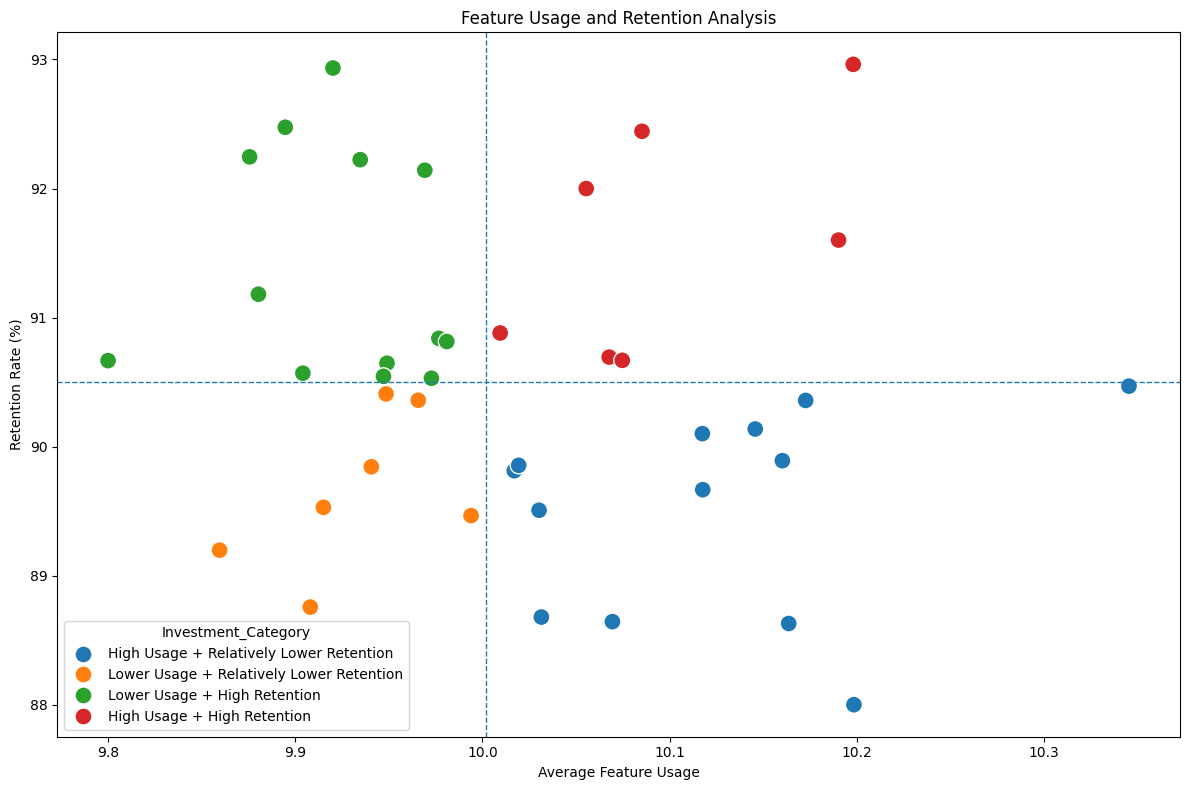

In [110]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=feature_analysis,
    x="Avg_Usage",
    y="Retention_Rate",
    hue="Investment_Category",
    s=150
)

plt.axvline(
    usage_median,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    retention_median,
    linestyle="--",
    linewidth=1
)

plt.title("Feature Usage and Retention Analysis")
plt.xlabel("Average Feature Usage")
plt.ylabel("Retention Rate (%)")

plt.tight_layout()
plt.show()

In [111]:
segment_counts = (
    user_behavior["User_Segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = [
    "User_Segment",
    "User_Count"
]

display(segment_counts)

,User_Segment,User_Count
0,Low Engagement,243
1,Highly Engaged,227
2,Moderately Engaged,30


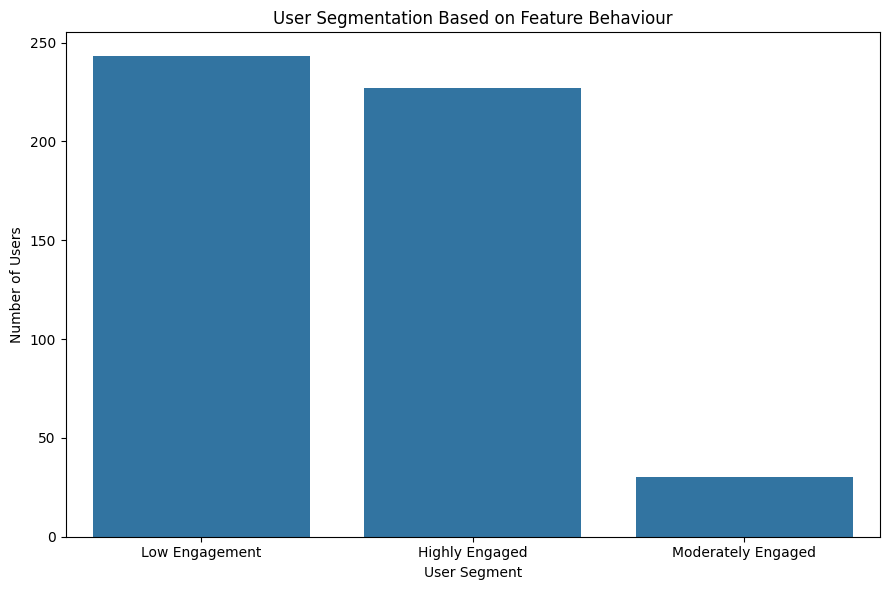

In [112]:
plt.figure(figsize=(9,6))

sns.barplot(
    data=segment_counts,
    x="User_Segment",
    y="User_Count"
)

plt.title("User Segmentation Based on Feature Behaviour")
plt.xlabel("User Segment")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

In [113]:
segment_retention_final = (
    user_behavior
    .groupby("User_Segment")
    .agg(
        Users=("User_ID", "count"),
        Retention_Rate=("Retention", "mean"),
        Avg_Feature_Usage=("Total_Feature_Usage", "mean"),
        Avg_Features_Used=("Features_Used", "mean"),
        Avg_Session_Count=("Session_Count", "mean")
    )
    .reset_index()
)

segment_retention_final["Retention_Rate"] *= 100

display(
    segment_retention_final.sort_values(
        "Retention_Rate",
        ascending=False
    )
)

,User_Segment,Users,Retention_Rate,Avg_Feature_Usage,Avg_Features_Used,Avg_Session_Count
2,Moderately Engaged,30,93.333333,521.566667,28.300000,52.266667
0,Highly Engaged,227,92.070485,652.387665,32.127753,64.964758
1,Low Engagement,243,87.242798,357.144033,23.316872,35.740741


In [114]:
model_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy_score(y_test, y_pred_tuned),
        balanced_accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned, zero_division=0),
        recall_score(y_test, y_pred_tuned, zero_division=0),
        f1_score(y_test, y_pred_tuned, zero_division=0)
    ]
})

model_results["Score"] = model_results["Score"].round(4)

display(model_results)

,Metric,Score
0,Accuracy,0.7200
1,Balanced Accuracy,0.4000
2,Precision,0.8780
3,Recall,0.8000
4,F1 Score,0.8372


In [115]:
print("=" * 60)
print("DS DAY 01 - SOFTWARE PRODUCT FEATURE ANALYTICS")
print("=" * 60)

print("\nDATASET")
print("Users:", user_behavior["User_ID"].nunique())
print("Features:", analysis_df["Feature_ID"].nunique())
print("Records:", len(analysis_df))

print("\nRETENTION")
print("Retained:", (user_behavior["Retention"] == 1).sum())
print("Churned:", (user_behavior["Retention"] == 0).sum())
print(
    "Retention Rate:",
    round(user_behavior["Retention"].mean() * 100, 2),
    "%"
)

print("\nUSER SEGMENTS")
print(user_behavior["User_Segment"].value_counts())

print("\nMODEL")
print("Accuracy:", round(accuracy_score(y_test, y_pred_tuned), 4))
print(
    "Balanced Accuracy:",
    round(balanced_accuracy_score(y_test, y_pred_tuned), 4)
)
print("Precision:", round(precision_score(
    y_test, y_pred_tuned, zero_division=0
), 4))
print("Recall:", round(recall_score(
    y_test, y_pred_tuned, zero_division=0
), 4))
print("F1:", round(f1_score(
    y_test, y_pred_tuned, zero_division=0
), 4))

print("\nTOP MODEL FEATURES")
display(tuned_importance.head(5))

DS DAY 01 - SOFTWARE PRODUCT FEATURE ANALYTICS

DATASET
Users: 500
Features: 40
Records: 25000

RETENTION
Retained: 449
Churned: 51
Retention Rate: 89.8 %

USER SEGMENTS
User_Segment
Low Engagement        243
Highly Engaged        227
Moderately Engaged     30
Name: count, dtype: int64

MODEL
Accuracy: 0.72
Balanced Accuracy: 0.4
Precision: 0.878
Recall: 0.8
F1: 0.8372

TOP MODEL FEATURES


,Feature,Importance
5,Tenure_Months,0.300652
4,Session_Duration,0.287373
1,Avg_Feature_Usage,0.224817
2,Features_Used,0.075404
3,Session_Count,0.060560


In [117]:
import joblib

In [118]:
# Save final datasets
analysis_df.to_csv(
    "/content/DS_Day01_14_Final_Analysis_Dataset.csv",
    index=False
)

feature_analysis.to_csv(
    "/content/DS_Day01_14_Final_Feature_Analysis.csv",
    index=False
)

user_behavior.to_csv(
    "/content/DS_Day01_14_Final_User_Segmentation.csv",
    index=False
)

tuned_importance.to_csv(
    "/content/DS_Day01_14_Final_Feature_Importance.csv",
    index=False
)

model_results.to_csv(
    "/content/DS_Day01_14_Model_Results.csv",
    index=False
)

joblib.dump(
    best_dt,
    "/content/DS_Day01_14_Final_Decision_Tree.pkl"
)

print("All project files saved successfully!")

All project files saved successfully!


In [119]:
import os

files = [
    "DS_Day01_14_Final_Analysis_Dataset.csv",
    "DS_Day01_14_Final_Feature_Analysis.csv",
    "DS_Day01_14_Final_User_Segmentation.csv",
    "DS_Day01_14_Final_Feature_Importance.csv",
    "DS_Day01_14_Model_Results.csv",
    "DS_Day01_14_Final_Decision_Tree.pkl"
]

for file in files:
    path = "/content/" + file
    print("✅" if os.path.exists(path) else "❌", file)

✅ DS_Day01_14_Final_Analysis_Dataset.csv
✅ DS_Day01_14_Final_Feature_Analysis.csv
✅ DS_Day01_14_Final_User_Segmentation.csv
✅ DS_Day01_14_Final_Feature_Importance.csv
✅ DS_Day01_14_Model_Results.csv
✅ DS_Day01_14_Final_Decision_Tree.pkl
